In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
plt.rcParams['font.family']

['sans-serif']

In [ ]:
infile = 'ForSimulation_Adults.xlsx'
outfile = 'Simulation_Adults.pdf'

In [26]:
parts = re.split(r'[._]', outfile)
print(parts)  # Output: ['example', 'file', 'name', 'txt']
title = parts[1]

['Simulation', 'Adults', 'pdf']


In [28]:
title = title [:-1] +" "+ "Speakers"

In [29]:
title

'Adult Speakers'

In [5]:
df = pd.read_excel(infile)

In [6]:
df.columns

Index(['Class', 'Property', 'Lexical_p0', 'Experimental_phat', 'Raw_successes',
       'n_limiting'],
      dtype='object')

In [7]:
df.iloc[0:4]

,Class,Property,Lexical_p0,Experimental_phat,Raw_successes,n_limiting
0,aF,APU,0.2259,0.269841,255,105
1,aF,PU,0.5810,0.711111,672,105
2,iF,APU,0.6017,0.140741,133,105
3,iF,PU,0.1576,0.760847,719,105


In [8]:
number_of_simulations = 1000
number_of_participants = df.iloc[0]['n_limiting'] 
print(f"Number of Participants: {number_of_participants}")
number_of_word_clusters = 9

Number of Participants: 105


In [9]:
rng = np.random.default_rng(16121968)

In [10]:
person_bias = rng.normal(loc=0, scale=0.1, size=2) # Adds noise with mean 0 and stddev 0.1
print(person_bias)

[-0.0609648  -0.02165146]


In [11]:
lexical_dict = {}
for class_value in df['Class'].unique():
    apu_row = df[(df['Class'] == class_value) & (df['Property'] == 'APU')]
    pu_row = df[(df['Class'] == class_value) & (df['Property'] == 'PU')]
    apu_val = apu_row['Lexical_p0'].values[0] if not apu_row.empty else None
    pu_val = pu_row['Lexical_p0'].values[0] if not pu_row.empty else None
    lexical_dict[class_value] = [apu_val, pu_val]
print(lexical_dict)

{'aF': [np.float64(0.2259), np.float64(0.581)], 'iF': [np.float64(0.6017), np.float64(0.1576)], 'iN': [np.float64(0.0097), np.float64(0.9542)], 'isM': [np.float64(0.015), np.float64(0.5415)], 'maN': [np.float64(0.99999), np.float64(1e-05)], 'oN': [np.float64(0.6256), np.float64(0.265)], 'osM': [np.float64(0.3565), np.float64(0.1682)]}


In [12]:
actual_results_dict = {}
for class_value in df['Class'].unique():
    apu_row = df[(df['Class'] == class_value) & (df['Property'] == 'APU')]
    pu_row = df[(df['Class'] == class_value) & (df['Property'] == 'PU')]
    apu_val = apu_row['Experimental_phat'].values[0] if not apu_row.empty else None
    pu_val = pu_row['Experimental_phat'].values[0] if not pu_row.empty else None
    actual_results_dict[class_value] = [apu_val, pu_val]
print(actual_results_dict)

{'aF': [np.float64(0.2698412698412698), np.float64(0.7111111111111111)], 'iF': [np.float64(0.1407407407407407), np.float64(0.7608465608465609)], 'iN': [np.float64(0.08465608465608465), np.float64(0.8603174603174604)], 'isM': [np.float64(0.0455026455026455), np.float64(0.7544973544973544)], 'maN': [np.float64(0.8984126984126984), np.float64(0.09523809523809523)], 'oN': [np.float64(0.6021164021164022), np.float64(0.3365079365079365)], 'osM': [np.float64(0.4835978835978836), np.float64(0.3650793650793651)]}


In [13]:
def individual_experiment(number_of_word_clusters):
    result = {}
    person_bias = rng.normal(loc=0, scale=0.1, size=2) # Adds noise with mean 0 and stddev 0.1
    person_probs_dict = { k: [v[0] + person_bias[0], v[1] + person_bias[1], 1 - (v[0] + person_bias[0] + v[1] + person_bias[1])] for k, v in lexical_dict.items() }
    
    for k, v in person_probs_dict.items():
        a = min(max(v[0], 0), 1)
        b = min(max(v[1], 0), 1)
        c = 1 - (a + b)
        if c < 0:
            c = 0
            if a + b > 1:
                total = a + b
                a = a / total
                b = b / total
        person_probs_dict[k] = [a, b, c]

    for class_value in df['Class'].unique():
        #print(person_probs_dict[class_value])
        result[class_value] = rng.choice(3, size=number_of_word_clusters, p=person_probs_dict[class_value])
    return result
    

In [14]:
rs = individual_experiment(number_of_word_clusters)

In [15]:
rs

{'aF': array([2, 1, 1, 0, 1, 1, 1, 1, 1]),
 'iF': array([1, 0, 0, 2, 0, 0, 2, 0, 2]),
 'iN': array([1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'isM': array([2, 2, 1, 0, 1, 1, 1, 1, 1]),
 'maN': array([1, 0, 0, 0, 0, 0, 0, 0, 0]),
 'oN': array([0, 0, 1, 1, 0, 1, 1, 1, 0]),
 'osM': array([0, 1, 0, 2, 2, 1, 2, 0, 2])}

In [16]:
def count_choices_per_class(results):
    counts_per_class = {}
    for class_value, choices in results.items():
        counts = Counter(choices)
        counts_per_class[class_value] = {
            'APU': counts.get(0, 0)/len(choices),
            'PU': counts.get(1, 0)/len(choices),
            'U': counts.get(2, 0)/len(choices)  
        }
    return counts_per_class

In [17]:
counts_per_class = count_choices_per_class(rs)
print(counts_per_class)

{'aF': {'APU': 0.1111111111111111, 'PU': 0.7777777777777778, 'U': 0.1111111111111111}, 'iF': {'APU': 0.5555555555555556, 'PU': 0.1111111111111111, 'U': 0.3333333333333333}, 'iN': {'APU': 0.0, 'PU': 1.0, 'U': 0.0}, 'isM': {'APU': 0.1111111111111111, 'PU': 0.6666666666666666, 'U': 0.2222222222222222}, 'maN': {'APU': 0.8888888888888888, 'PU': 0.1111111111111111, 'U': 0.0}, 'oN': {'APU': 0.4444444444444444, 'PU': 0.5555555555555556, 'U': 0.0}, 'osM': {'APU': 0.3333333333333333, 'PU': 0.2222222222222222, 'U': 0.4444444444444444}}


In [18]:
def complete_experiment(number_of_participants, number_of_word_clusters):
    combined_results = {class_value: [] for class_value in df['Class'].unique()}
    for _ in range(number_of_participants):
        rs = individual_experiment(number_of_word_clusters)
        for class_value in df['Class'].unique():
            combined_results[class_value].extend(rs[class_value])
    return combined_results

In [19]:
combined_results = complete_experiment(number_of_participants, number_of_word_clusters)

In [20]:
for class_value, choices in combined_results.items():
    print(f"Class: {class_value}, Choices: {len(choices)}")

Class: aF, Choices: 945
Class: iF, Choices: 945
Class: iN, Choices: 945
Class: isM, Choices: 945
Class: maN, Choices: 945
Class: oN, Choices: 945
Class: osM, Choices: 945


In [21]:
counts_per_class = count_choices_per_class(combined_results)
print(counts_per_class)

{'aF': {'APU': 0.21375661375661376, 'PU': 0.5989417989417989, 'U': 0.1873015873015873}, 'iF': {'APU': 0.5777777777777777, 'PU': 0.1693121693121693, 'U': 0.2529100529100529}, 'iN': {'APU': 0.031746031746031744, 'PU': 0.9259259259259259, 'U': 0.042328042328042326}, 'isM': {'APU': 0.056084656084656084, 'PU': 0.5619047619047619, 'U': 0.382010582010582}, 'maN': {'APU': 0.9375661375661376, 'PU': 0.03597883597883598, 'U': 0.026455026455026454}, 'oN': {'APU': 0.5968253968253968, 'PU': 0.2761904761904762, 'U': 0.12698412698412698}, 'osM': {'APU': 0.37566137566137564, 'PU': 0.17037037037037037, 'U': 0.45396825396825397}}


In [22]:
simulation_results = {class_value: [] for class_value in df['Class'].unique()}
for _ in range(number_of_simulations):
    combined_results = complete_experiment(number_of_participants, number_of_word_clusters)
    counts_per_class = count_choices_per_class(combined_results)
    for class_value in df['Class'].unique():
        x = counts_per_class[class_value]['APU']
        y = counts_per_class[class_value]['PU']
        simulation_results[class_value].append((x, y))
print(simulation_results)

{'aF': [(0.2328042328042328, 0.5724867724867725), (0.23703703703703705, 0.5798941798941799), (0.23597883597883598, 0.5724867724867725), (0.24656084656084656, 0.5746031746031746), (0.21481481481481482, 0.5661375661375662), (0.20105820105820105, 0.5851851851851851), (0.21375661375661376, 0.564021164021164), (0.2571428571428571, 0.5650793650793651), (0.22857142857142856, 0.6074074074074074), (0.2201058201058201, 0.582010582010582), (0.2105820105820106, 0.5851851851851851), (0.22433862433862434, 0.5756613756613757), (0.2074074074074074, 0.5777777777777777), (0.20952380952380953, 0.6063492063492063), (0.22857142857142856, 0.5746031746031746), (0.2677248677248677, 0.5862433862433862), (0.23597883597883598, 0.5894179894179894), (0.21904761904761905, 0.5597883597883598), (0.18412698412698414, 0.6264550264550265), (0.23597883597883598, 0.5661375661375662), (0.24126984126984127, 0.5682539682539682), (0.24444444444444444, 0.5714285714285714), (0.2, 0.5957671957671957), (0.19682539682539682, 0.597

In [23]:
# Prepare DataFrame for plotting
plot_data = []
for class_value, points in simulation_results.items():
    for x, y in points:
        plot_data.append({'Class': class_value, 'APU': x, 'PU': y})
df_plot = pd.DataFrame(plot_data)

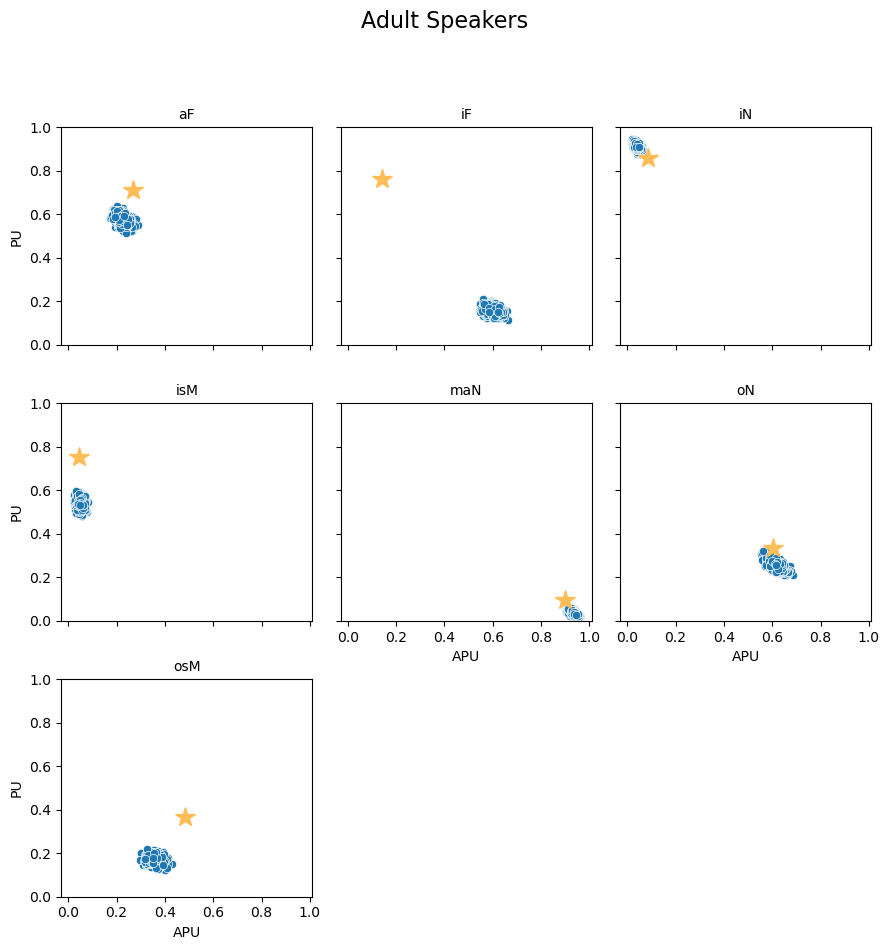

In [32]:
g = sns.FacetGrid(df_plot, col='Class', col_wrap=3, sharex=True, sharey=True, despine=False)
g.map_dataframe(sns.scatterplot, x='APU', y='PU')

# Ensure vertical axis includes 1.0 tick
g.set(ylim=(0, 1))
yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
for ax in g.axes.flat:
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)

# Add yellow star for actual results
for ax, class_value in zip(g.axes.flat, df_plot['Class'].unique()):
    actual = actual_results_dict[class_value]
    ax.plot(actual[0], actual[1], marker='*', color='#ffbd58', markersize=15, label='Actual')
    # ax.legend()

g.set_axis_labels('APU', 'PU')
g.set_titles(col_template="{col_name}")
plt.suptitle(title, fontsize=16, y=1.05)
plt.savefig(outfile, bbox_inches='tight')
plt.tight_layout()
plt.show()